# Loss: midiendo el error del modelo
**Basado en**: *Neural Networks from Scratch* - Capítulo 5 (Calculating Network Error with Loss)

**Objetivo**: entender como se mide el error de una red neuronal y por que usamos
la entropía cruzada categórica en lugar de otras métricas mas intuitivas como accuracy.

**La pregunta clave**: si dos modelos tienen el mismo accuracy, ¿son igualmente buenos?

**Estructura del notebook:**
1. Accuracy vs confianza: por que accuracy no es suficiente
2. Que es el loss (función de coste)
3. Entropía cruzada categórica - desde cero
4. Logaritmo natural y su relación con confianza
5. Loss en batches: targets dispersos y one-hot
6. Clipping: prevenir log(0) = infinito
7. La clase Loss y el pipeline completo
8. Ejercicio de decisión

---

In [1]:
%pip install -q nnfs

import numpy as np
import matplotlib.pyplot as plt
import math
import nnfs
from nnfs.datasets import spiral_data
import os

nnfs.init()
os.makedirs('images', exist_ok=True)
%matplotlib inline
print(f'NumPy {np.__version__}')
print('[OK] Entorno listo')


Note: you may need to restart the kernel to use updated packages.
NumPy 1.26.4
[OK] Entorno listo


In [2]:
# Clases de los notebooks anteriores (necesarias para el pipeline completo)

class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases  = np.zeros((1, n_neurons))
    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases

class Activation_ReLU:
    def forward(self, inputs):
        self.output = np.maximum(0, inputs)

class Activation_Softmax:
    def forward(self, inputs):
        exp_values   = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        self.output  = probabilities

print('[OK] Layer_Dense, Activation_ReLU, Activation_Softmax definidas')

[OK] Layer_Dense, Activation_ReLU, Activation_Softmax definidas


---
## 1. Accuracy vs confianza: por que accuracy no basta

Imagina dos predicciones del mismo modelo, ambas correctas:

```
Predicción A: [0.22, 0.60, 0.18]  <- clase 1 predicha (correcto)
Predicción B: [0.32, 0.36, 0.32]  <- clase 1 predicha (correcto)
```

La **accuracy** es idéntica en ambos casos: 1/1.
Pero ¿son realmente igual de buenas?

**No**: el modelo A esta mucho mas seguro (0.60 vs 0.36).
El modelo B apenas supera el umbral - una pequeña perturbación podria cambiar la predicción.

La accuracy no captura esta diferencia.
Necesitamos una métrica que:
1. Premie la confianza en la clase correcta
2. Penalice la confianza en clases incorrectas
3. Sea diferenciable (para poder calcular gradientes en el entrenamiento)

Esa métrica es el **loss** (función de coste o error).

In [3]:
# Demostracion: accuracy identica, confianza muy diferente

pred_A = np.array([0.22, 0.60, 0.18])  # clase correcta: 1
pred_B = np.array([0.32, 0.36, 0.32])  # clase correcta: 1

clase_correcta = 1  # argmax deberia ser 1

acc_A = int(np.argmax(pred_A) == clase_correcta)
acc_B = int(np.argmax(pred_B) == clase_correcta)

print('=== Accuracy ===')
print(f'Prediccion A: {pred_A}  argmax={np.argmax(pred_A)}  accuracy={acc_A}')
print(f'Prediccion B: {pred_B}  argmax={np.argmax(pred_B)}  accuracy={acc_B}')
print('Accuracy identica: no distingue entre predicciones seguras e inseguras')

print()
print('=== Loss (Cross-Entropy) ===')
loss_A = -math.log(pred_A[clase_correcta])
loss_B = -math.log(pred_B[clase_correcta])
print(f'Loss A = -log({pred_A[clase_correcta]:.2f}) = {loss_A:.4f}  (prediccion segura)')
print(f'Loss B = -log({pred_B[clase_correcta]:.2f}) = {loss_B:.4f}  (prediccion insegura)')
print()
print('Loss menor = prediccion mejor.')
print('El objetivo del entrenamiento: minimizar el loss promedio sobre todo el batch.')

=== Accuracy ===
Prediccion A: [0.22 0.6  0.18]  argmax=1  accuracy=1
Prediccion B: [0.32 0.36 0.32]  argmax=1  accuracy=1
Accuracy identica: no distingue entre predicciones seguras e inseguras

=== Loss (Cross-Entropy) ===
Loss A = -log(0.60) = 0.5108  (prediccion segura)
Loss B = -log(0.36) = 1.0217  (prediccion insegura)

Loss menor = prediccion mejor.
El objetivo del entrenamiento: minimizar el loss promedio sobre todo el batch.


---
## 2. Que es el loss

El **loss** (o *cost function*) es un número que cuantifica cuanto se equivoca el modelo.

- Loss = 0: el modelo es perfecto (en ese batch)
- Loss > 0: hay error. Mayor loss = mayor error
- Loss = infinito: el modelo asigno 0% de confianza a la clase correcta

El loss tiene dos requisitos funcionales:
1. **Diferenciable**: podemos calcular su gradiente para ajustar pesos
2. **Sensible a la confianza**: no solo a si acerto o no

Para clasificación multiclase con Softmax, la función de loss estándar es la
**Entropía Cruzada Categórica** (*Categorical Cross-Entropy*):

```
Loss_i = -log(y_pred[clase_correcta])
```

Donde `y_pred[clase_correcta]` es la confianza que el modelo asigna a la clase real.

> Loss total del batch = media de los losses individuales de cada muestra.

---
## 3. Entropía cruzada categórica - desde cero

La formula completa compara dos distribuciones de probabilidad:
la real (one-hot: `[1, 0, 0]`) y la predicha (Softmax: `[0.7, 0.1, 0.2]`).

```
L = - sum_j [y_true[j] * log(y_pred[j])]
```

Cuando `y_true` es one-hot, todos los terminos con `y_true[j] = 0` desaparecen,
y solo queda:

```
L = -log(y_pred[clase_correcta])
```

Esta simplificación - **negative log likelihood** - es lo que implementamos en práctica.

Por que el logaritmo:
- Convierte multiplicaciones en sumas (conveniencia algebraica)
- Penaliza fuertemente la baja confianza (log crece muy lento hacia 1, cae rápido hacia 0)
- Es la base de la teoría de la información de Shannon

In [4]:
# Entropia cruzada categorica - formula completa

import math

softmax_output = [0.7, 0.1, 0.2]
target_output  = [1, 0, 0]           # one-hot: la clase correcta es la 0

# Formula completa (suma sobre todas las clases)
loss_completo = -(math.log(softmax_output[0]) * target_output[0] +
                  math.log(softmax_output[1]) * target_output[1] +
                  math.log(softmax_output[2]) * target_output[2])
print(f'Loss completo:      {loss_completo:.6f}')

# Simplificacion one-hot: solo importa la clase correcta
loss_simplificado = -math.log(softmax_output[0])
print(f'Loss simplificado:  {loss_simplificado:.6f}  <- identico')

print()
print('Los terminos target[1] y target[2] son 0 -> se anulan.')
print('Solo queda -log(confianza_en_clase_correcta).')

Loss completo:      0.356675
Loss simplificado:  0.356675  <- identico

Los terminos target[1] y target[2] son 0 -> se anulan.
Solo queda -log(confianza_en_clase_correcta).


---
## 4. Logaritmo natural: intuición sobre confianza y loss

El logaritmo natural `ln(x)` cumple: si `e^y = x`, entonces `ln(x) = y`.

Propiedades clave para nosotros:
- `ln(1)  = 0`   → modelo 100% seguro → loss = 0 (perfecto)
- `ln(0.9) ≈ -0.10` → loss ≈ 0.10 (muy confiado, pequeño error)
- `ln(0.5) ≈ -0.69` → loss ≈ 0.69 (50% de confianza)
- `ln(0.1) ≈ -2.30` → loss ≈ 2.30 (muy inseguro, alto error)
- `ln(0)   = -inf`  → loss = infinito (modelo totalmente equivocado)

La curva del logaritmo penaliza cada vez mas severamente
a medida que la confianza se acerca a 0.

In [5]:
# Tabla de confianza vs loss

print(f"{'Confianza en clase correcta':>35} | {'Loss = -log(confianza)':>25}")
print('-' * 65)
for conf in [1.0, 0.95, 0.9, 0.8, 0.6, 0.4, 0.2, 0.1, 0.05, 0.01]:
    loss = -math.log(conf)
    barra = '|' * int(loss * 5)
    print(f'{conf:>35.2f} | {loss:>8.4f}  {barra}')

print()
print('Interpretacion:')
print(' - Confianza alta (>0.9) -> loss pequeno: modelo casi perfecto')
print(' - Confianza baja (<0.1) -> loss grande:  modelo muy incierto o equivocado')
print(' - Confianza = 0         -> loss = inf:   el modelo asigna 0% a la clase correcta')

        Confianza en clase correcta |    Loss = -log(confianza)
-----------------------------------------------------------------
                               1.00 |  -0.0000  
                               0.95 |   0.0513  
                               0.90 |   0.1054  
                               0.80 |   0.2231  |
                               0.60 |   0.5108  ||
                               0.40 |   0.9163  ||||
                               0.20 |   1.6094  ||||||||
                               0.10 |   2.3026  |||||||||||
                               0.05 |   2.9957  ||||||||||||||
                               0.01 |   4.6052  |||||||||||||||||||||||

Interpretacion:
 - Confianza alta (>0.9) -> loss pequeno: modelo casi perfecto
 - Confianza baja (<0.1) -> loss grande:  modelo muy incierto o equivocado
 - Confianza = 0         -> loss = inf:   el modelo asigna 0% a la clase correcta


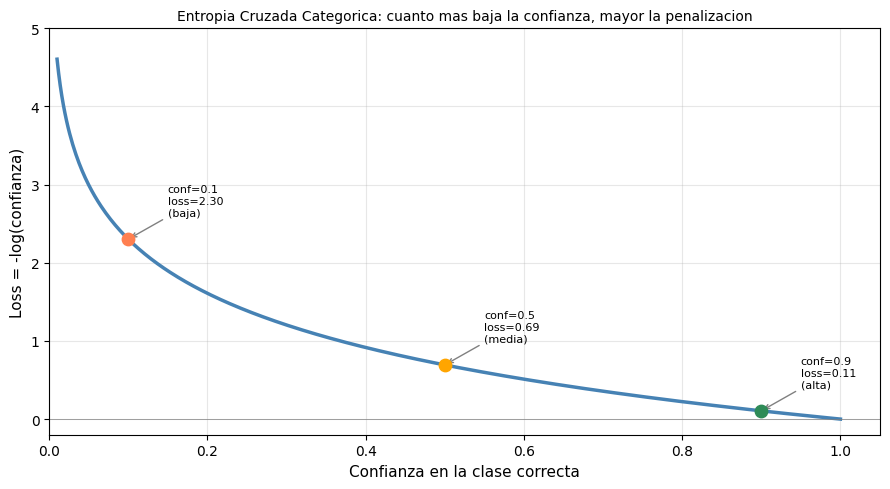

In [6]:
# Curva -log(x): visualizacion de como el loss penaliza la baja confianza

x = np.linspace(0.01, 1.0, 500)
y = -np.log(x)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, y, color='steelblue', linewidth=2.5)
ax.axhline(0, color='gray', linewidth=0.5)

# Marcar puntos clave
for conf, etiqueta in [(0.9, 'alta'), (0.5, 'media'), (0.1, 'baja')]:
    loss_val = -np.log(conf)
    ax.scatter([conf], [loss_val], s=80, zorder=5,
               color=['seagreen', 'orange', 'coral'][['alta','media','baja'].index(etiqueta)])
    ax.annotate(f'conf={conf}\nloss={loss_val:.2f}\n({etiqueta})',
                xy=(conf, loss_val), xytext=(conf + 0.05, loss_val + 0.3),
                fontsize=8, arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('Confianza en la clase correcta', fontsize=11)
ax.set_ylabel('Loss = -log(confianza)', fontsize=11)
ax.set_title('Entropia Cruzada Categorica: cuanto mas baja la confianza, mayor la penalizacion', fontsize=10)
ax.set_xlim(0, 1.05)
ax.set_ylim(-0.2, 5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/B03D_fig01.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')

---
## 5. Loss en batches: targets dispersos y one-hot

Las etiquetas de clase se pueden representar de dos formas:

**Targets dispersos** (*sparse*): un vector de indices de clase.
```python
y_true = [0, 1, 1]   # muestra 0 es clase 0, muestra 1 y 2 son clase 1
```

**Targets one-hot**: una matriz donde cada fila tiene un 1 en la clase correcta.
```python
y_true = [[1, 0, 0],   # clase 0
           [0, 1, 0],   # clase 1
           [0, 1, 0]]   # clase 1
```

La implementación debe manejar ambos formatos:
- Si `y_true.ndim == 1`: targets dispersos → indexar directamente
- Si `y_true.ndim == 2`: targets one-hot → multiplicar y sumar

> `spiral_data()` devuelve targets dispersos (enteros 0/1/2).
> Muchos datasets de Keras/TensorFlow usan one-hot.
> La clase Loss debe aceptar ambos.

In [7]:
# Loss en batch: indexacion numpy para targets dispersos

softmax_outputs = np.array([[0.7, 0.1, 0.2],
                             [0.1, 0.5, 0.4],
                             [0.02, 0.9, 0.08]])

class_targets = [0, 1, 1]  # dog, cat, cat (targets dispersos)

# Extraer la confianza en la clase correcta para cada muestra
# Metodo 1: bucle
confs_bucle = [softmax_outputs[i][class_targets[i]] for i in range(len(class_targets))]
print('Confianzas (bucle):  ', confs_bucle)

# Metodo 2: indexacion NumPy (mas eficiente)
confs_numpy = softmax_outputs[range(len(softmax_outputs)), class_targets]
print('Confianzas (NumPy):  ', confs_numpy)

# Loss por muestra
losses = -np.log(confs_numpy)
print('Loss por muestra:    ', losses)

# Loss promedio del batch
avg_loss = np.mean(losses)
print(f'Loss promedio batch: {avg_loss:.6f}')

Confianzas (bucle):   [0.7, 0.5, 0.9]
Confianzas (NumPy):   [0.7 0.5 0.9]
Loss por muestra:     [0.35667494 0.69314718 0.10536052]
Loss promedio batch: 0.385061


In [8]:
# Loss con targets one-hot (mismo resultado que con dispersos)

softmax_outputs = np.array([[0.7, 0.1, 0.2],
                             [0.1, 0.5, 0.4],
                             [0.02, 0.9, 0.08]])

# Los mismos targets en formato one-hot
class_targets_onehot = np.array([[1, 0, 0],   # dog  -> clase 0
                                  [0, 1, 0],   # cat  -> clase 1
                                  [0, 1, 0]])  # cat  -> clase 1

# Multiplicar y sumar: solo la confianza en la clase correcta sobrevive
correct_confidences = np.sum(softmax_outputs * class_targets_onehot, axis=1)
print('Confianzas (one-hot):', correct_confidences)

losses_onehot = -np.log(correct_confidences)
avg_loss_onehot = np.mean(losses_onehot)
print(f'Loss promedio:       {avg_loss_onehot:.6f}  <- identico al anterior')

print()
print('Verificacion: los dos formatos producen el mismo loss ->', np.isclose(avg_loss_onehot, 0.38506088))

Confianzas (one-hot): [0.7 0.5 0.9]
Loss promedio:       0.385061  <- identico al anterior

Verificacion: los dos formatos producen el mismo loss -> True


---
## 6. Clipping: prevenir log(0) = infinito

`-log(0)` es matemáticamente infinito. En NumPy produce `inf` y una advertencia.
Un solo `inf` en un batch hace que el loss promedio sea `inf` → el entrenamiento se rompe.

**Cuando ocurre**: cuando el modelo asigna 0% de confianza a la clase correcta.
Esto puede pasar especialmente al inicio del entrenamiento con pesos aleatorios.

**Solución**: recortar las predicciones para que nunca sean exactamente 0 ni 1:
```python
y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
```

Por que recortar por ambos lados:
- Por abajo `(1e-7)`: evita `log(0) = inf`
- Por arriba `(1 - 1e-7)`: evita que el loss sea negativo cuando la confianza > 1
  (no deberia ocurrir con Softmax bien implementada, pero es una salvaguarda)

El impacto en el loss es despreciable: `1e-7` es una diezmillonésima.

In [9]:
# Demostracion del problema y la solucion

import warnings
warnings.filterwarnings('error')  # para ver el warning como error

print('=== Sin clipping ===')
try:
    print(-np.log(0))
except RuntimeWarning as e:
    print(f'RuntimeWarning: {e}')
    print('log(0) = inf en NumPy (la operacion produce infinito)')

warnings.filterwarnings('default')

print()
print('=== Con clipping 1e-7 ===')
confianza_cero = 0.0
clipped = np.clip(confianza_cero, 1e-7, 1 - 1e-7)
print(f'-log({confianza_cero})    = inf (problema)')
print(f'-log({clipped:.0e}) = {-np.log(clipped):.4f}  (soluble, impacto despreciable)')

print()
print('=== Por que tambien clipear por arriba ===')
confianza_uno = 1.0
clipped_up = np.clip(confianza_uno, 1e-7, 1 - 1e-7)
print(f'-log(1.0)       = {-np.log(confianza_uno):.4f}  (correcto: loss = 0 para prediccion perfecta)')
print(f'-log(1+1e-7)    = {-np.log(1 + 1e-7):.2e}  (negativo: loss negativo, incorrecto)')
print(f'-log(1-1e-7)    = {-np.log(1 - 1e-7):.2e}  (positivo muy pequeno: correcto)')

=== Sin clipping ===
log(0) = inf en NumPy (la operacion produce infinito)

=== Con clipping 1e-7 ===
-log(0.0)    = inf (problema)
-log(1e-07) = 16.1181  (soluble, impacto despreciable)

=== Por que tambien clipear por arriba ===
-log(1.0)       = -0.0000  (correcto: loss = 0 para prediccion perfecta)
-log(1+1e-7)    = -1.00e-07  (negativo: loss negativo, incorrecto)
-log(1-1e-7)    = 1.00e-07  (positivo muy pequeno: correcto)


---
## 7. Las clases Loss y el pipeline completo

Juntamos todo en una arquitectura de clases siguiendo el libro NNFS:

- `Loss`: clase base con el metodo `calculate()` (promedia los losses por muestra)
- `Loss_CategoricalCrossentropy`: hereda de `Loss`, implementa `forward()` con clipping

Pipeline completo:
```
X → dense1 → relu1 → dense2 → softmax2 → loss_function.calculate(output, y_true)
                                          ↳ loss (escalar, el error del batch)
```

El loss escalar es lo que el optimizador (B04) usará para calcular
los gradientes y actualizar los pesos.

In [10]:
# Clase base Loss
class Loss:
    # Calcula el loss promedio del batch
    def calculate(self, output, y):
        # Llama al forward() de la subclase
        sample_losses = self.forward(output, y)
        # Promedio sobre el batch
        data_loss = np.mean(sample_losses)
        return data_loss


# Entropia Cruzada Categorica
class Loss_CategoricalCrossentropy(Loss):
    def forward(self, y_pred, y_true):
        samples = len(y_pred)

        # Clipping bilateral: evita log(0) y no sesga la media
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)

        # Targets dispersos (vector de indices)
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[
                range(samples),
                y_true
            ]
        # Targets one-hot (matriz)
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(
                y_pred_clipped * y_true,
                axis=1
            )

        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods


# Verificacion con los datos del libro
softmax_outputs = np.array([[0.7, 0.1, 0.2],
                              [0.1, 0.5, 0.4],
                              [0.02, 0.9, 0.08]])
class_targets_sparse = np.array([0, 1, 1])
class_targets_onehot = np.array([[1, 0, 0], [0, 1, 0], [0, 1, 0]])

loss_fn = Loss_CategoricalCrossentropy()

loss_sparse = loss_fn.calculate(softmax_outputs, class_targets_sparse)
loss_onehot = loss_fn.calculate(softmax_outputs, class_targets_onehot)

print(f'Loss con targets dispersos: {loss_sparse:.6f}')
print(f'Loss con targets one-hot:   {loss_onehot:.6f}')
print(f'Son identicos: {np.isclose(loss_sparse, loss_onehot)}')
print(f'Esperado: 0.385061')

Loss con targets dispersos: 0.385061
Loss con targets one-hot:   0.385061
Son identicos: True
Esperado: 0.385061


In [11]:
# Pipeline completo: todo junto
# Este es el codigo estandar del libro NNFS al final del capitulo 5

import numpy as np
import nnfs
from nnfs.datasets import spiral_data

nnfs.init()

# Dataset
X, y = spiral_data(samples=100, classes=3)

# Arquitectura
dense1      = Layer_Dense(2, 3)
activation1 = Activation_ReLU()
dense2      = Layer_Dense(3, 3)
activation2 = Activation_Softmax()
loss_function = Loss_CategoricalCrossentropy()

# Forward pass completo
dense1.forward(X)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
activation2.forward(dense2.output)

# Calcular loss
loss = loss_function.calculate(activation2.output, y)

# Calcular accuracy
predictions = np.argmax(activation2.output, axis=1)
accuracy = np.mean(predictions == y)

print('Primeras 5 predicciones de probabilidad:')
print(activation2.output[:5])
print()
print(f'Loss:     {loss:.4f}  (objetivo: minimizar esto durante el entrenamiento)')
print(f'Accuracy: {accuracy:.4f}  (con pesos aleatorios, esperado ~0.33)')
print()
print('[OK] Este pipeline es la base sobre la que se construye el entrenamiento.')
print('     El siguiente paso (B04) calcula los gradientes del loss y actualiza los pesos.')

Primeras 5 predicciones de probabilidad:
[[0.33333334 0.33333334 0.33333334]
 [0.3333332  0.3333332  0.33333364]
 [0.3333329  0.33333293 0.3333342 ]
 [0.3333326  0.33333263 0.33333477]
 [0.33333233 0.3333324  0.33333528]]

Loss:     1.0986  (objetivo: minimizar esto durante el entrenamiento)
Accuracy: 0.3400  (con pesos aleatorios, esperado ~0.33)

[OK] Este pipeline es la base sobre la que se construye el entrenamiento.
     El siguiente paso (B04) calcula los gradientes del loss y actualiza los pesos.


Loss inicial esperado con 3 clases (azar): 1.0986
  = -log(1/3) = -log(probabilidad uniforme)



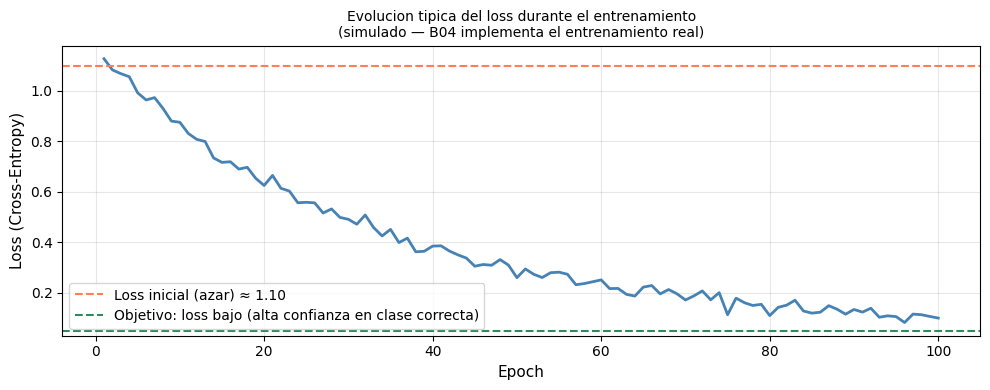

In [12]:
# Simulacion: como deberia evolucionar el loss durante el entrenamiento
# (sin backprop real - solo para ilustrar el concepto)

# Un loss tipico empieza alto (pesos aleatorios) y decrece con cada epoch
# El loss de un clasificador de 3 clases con pesos aleatorios es aproximadamente ln(3) ≈ 1.099

loss_inicial_esperado = -np.log(1/3)  # 1/3 de confianza = azar con 3 clases
print(f'Loss inicial esperado con 3 clases (azar): {loss_inicial_esperado:.4f}')
print(f'  = -log(1/3) = -log(probabilidad uniforme)')
print()

# Curva de loss simulada (puramente ilustrativa)
np.random.seed(42)
epochs = np.arange(1, 101)
loss_curva = loss_inicial_esperado * np.exp(-0.03 * epochs) + 0.05 + 0.02 * np.random.randn(100)
loss_curva = np.maximum(loss_curva, 0.05)  # floor

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(epochs, loss_curva, color='steelblue', linewidth=2)
ax.axhline(loss_inicial_esperado, color='coral', linestyle='--', linewidth=1.5,
           label=f'Loss inicial (azar) ≈ {loss_inicial_esperado:.2f}')
ax.axhline(0.05, color='seagreen', linestyle='--', linewidth=1.5,
           label='Objetivo: loss bajo (alta confianza en clase correcta)')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss (Cross-Entropy)', fontsize=11)
ax.set_title('Evolucion tipica del loss durante el entrenamiento\n(simulado - B04 implementa el entrenamiento real)', fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/B03D_fig02.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')

---
## 8. Ejercicio de decisión

### Caso: evaluación de un modelo de scoring de crédito en la empresa

El equipo financiero ha entrenado un modelo para aprobar o rechazar solicitudes de crédito.
El modelo es un clasificador binario (aprobado / rechazado).

El informe de evaluación muestra:
- **Accuracy: 92%**
- **Loss final: 0.43**

El equipo esta satisfecho porque el 92% de los casos se clasifican correctamente.

---

**Pregunta 1 - Accuracy vs Loss**:
El loss es 0.43. Con accuracy del 92%, ¿te parece un loss alto o bajo?
¿Qué te indica este loss sobre el modelo?

**Pregunta 2 - El coste asimétrico del error**:
En scoring de crédito, hay dos tipos de error:
- Falso positivo: aprobar a alguien que no pagara (pérdida financiera)
- Falso negativo: rechazar a alguien que si pagaria (pérdida de negocio)

¿Deberia el loss tratar ambos tipos de error de la misma manera?
¿Qué modificación al loss permitiria penalizar mas un tipo de error?

**Pregunta 3 - Loss en producción**:
El modelo ya esta desplegado. ¿Monitorizarias el loss en producción?
¿Que te diria si el loss empieza a subir semanas despues del despliegue?

**Pregunta 4 - Umbral de decisión**:
El modelo produce probabilidades: `[P(rechazar), P(aprobar)]`.
Si usas `argmax` para decidir, el umbral es 0.5.
¿En qué casos querrías usar un umbral diferente?

---
*Escribe tus respuestas en la celda siguiente.*

### Mis respuestas

**Pregunta 1 - Accuracy vs Loss:**

*(escribe aqui)*

**Pregunta 2 - El coste asimétrico del error:**

*(escribe aqui)*

**Pregunta 3 - Loss en producción:**

*(escribe aqui)*

**Pregunta 4 - Umbral de decisión:**

*(escribe aqui)*

---

<!--
CRITERIOS DE EVALUACIÓN (para el instructor)

Pregunta 1:
Un loss de 0.43 con 92% de accuracy indica que el modelo acerta bastante
pero no esta muy seguro en sus predicciones correctas.
-log(0.65) ≈ 0.43 -> el modelo tiene de media ~65% de confianza en sus predicciones correctas.
Un modelo excelente tendria loss < 0.1 (confianza > 90% en promedio).
Respuesta solida: menciona que accuracy alta + loss alto indica confianza baja,
y que esto puede ser un riesgo si el sistema actua automáticamente.

Pregunta 2:
El loss estándar (cross-entropy) trata ambos errores por igual.
Para errores asimétricos: weighted cross-entropy o cost-sensitive learning.
En la práctica: ajustar el umbral de decisión es mas sencillo que modificar el loss.
Respuesta que menciona solo una de estas dos opciones = parcialmente correcta.
Respuesta que explica que el coste de un FP y un FN es diferente = correcta.

Pregunta 3:
Si: el loss en producción es un indicador temprano de degradación del modelo (data drift).
Si el loss sube: la distribución de los datos de producción esta cambiando respecto al entrenamiento.
El modelo puede seguir teniendo buena accuracy en el corto plazo pero estar deteriorándose.
Señal de que puede ser necesario reentrenar.
Respuesta que menciona data drift y reentrenamiento = correcta.

Pregunta 4:
Umbral menor que 0.5 para aprobar (mas conservador): cuando el coste de un FP es alto.
Umbral mayor que 0.5 para aprobar (mas liberal): cuando el coste de un FN es alto.
En crédito: generalmente se usa un umbral alto para aprobación (conservador).
Respuesta que identifica la relación entre umbral y coste del error = correcta.
-->

---
## Puntos clave del B03D

1. **Accuracy no distingue entre predicciones seguras e inseguras**:
   el loss captura la confianza y penaliza la incertidumbre.

2. **Entropía Cruzada Categórica = `-log(confianza_clase_correcta)`**:
   loss = 0 si el modelo es perfecto, loss = infinito si asigna 0% a la clase correcta.

3. **Clipping bilateral** `[1e-7, 1-1e-7]`: evita log(0) sin sesgar el loss.

4. **Dos formatos de targets**: dispersos (indices) y one-hot (matrices).
   La implementación debe manejar ambos.

5. **Loss inicial esperado con N clases = ln(N)**:
   con 3 clases → ln(3) ≈ 1.099. Si el loss inicial es muy distinto, algo va mal.

6. **El loss es lo que el optimizador minimiza**: no la accuracy.
   La accuracy es la métrica que le importa al negocio; el loss es la métrica que guia el aprendizaje.

---
**Siguiente notebook** - B04: El Aprendizaje como Optimización
Implementaremos backpropagation y gradient descent para que los pesos
se ajusten automáticamente y el loss disminuya con cada epoch.